In [4]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = "cs231n/my_assignments/assignment1/"
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/cs231n/my_assignments/assignment1/cs231n/datasets
/content/drive/My Drive/cs231n/my_assignments/assignment1


In [5]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline 
"""
使用%matplotlib命令可以将matplotlib的图表直接嵌入到Notebook之中，或者使用指定的界面库显示图表，它有一个参数指定matplotlib图表的显示方式。
inline表示将图表嵌入到Notebook中。
"""
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置画布大小
plt.rcParams['image.interpolation'] = 'nearest' # 差值方式
plt.rcParams['image.cmap'] = 'gray' # 灰度空间

%load_ext autoreload
%autoreload 2
"""
autoreload 0  禁用自动加载
autoreload 1  只会自动重新加载使用 %aimport 函数导入的模块
autoreload 2  自动重新加载所有模块。 使编写和测试模块变得更加容易的好方法
"""

'\nautoreload 0  禁用自动加载\nautoreload 1  只会自动重新加载使用 %aimport 函数导入的模块\nautoreload 2  自动重新加载所有模块。 使编写和测试模块变得更加容易的好方法\n'

In [6]:
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'   #以一个变量来存储数据集的位置

# 清理变量以防多次加载数据，因为下面要再用
try:
  del X_train, y_train
  del X_test, y_test
  print("Clear previously loaded data.")
except:
  pass #pass用于创建空的代码块

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir) # 产生训练集和测试集

# 返回训练集和测试集的大小
print('Training data shape: ', X_train.shape) 
# 根据输出 X_train 中有50000个元素，每个元素为一个图像， 每个图像的像素点为32 * 32 ， 每个像素点中有一个RGB 及红黄蓝
# 所以 X_train 是四维数组
print('Training labels shape: ', y_train.shape)
# y_train 为X_train对应的标签，所以是一维数组
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


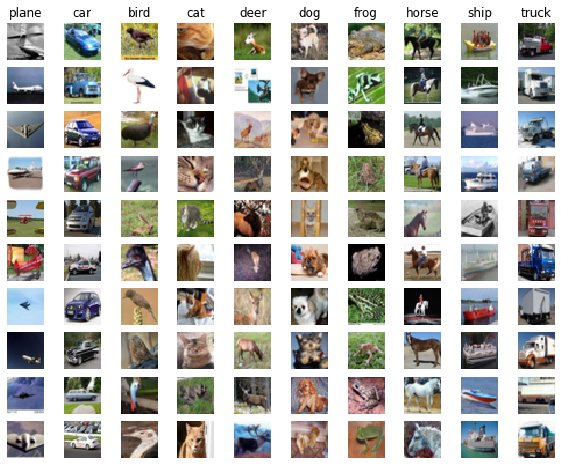

In [7]:
# 展示每个训练类的一些例子

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']  # 分类标签, 这个已经在数据集上约定好了
num_classes = len(classes)  # 标签数量
samples_per_class = 10  # 示例数量
for y, cls in enumerate(classes):  # 枚举，并把 key 和 value 存储在y, cls上
    # y 0 到 9， cls是对应的value
    idxs = np.flatnonzero(y_train == y)  # numpy.flatnonzero(): 该函数输入一个矩阵，返回扁平化后矩阵中非零元素 或者说 值为真的位置
    # 每个y_train 上只存储了 索引， 并不是名称 plane之类的从， plane对应的是 0 以此类推
    # 从y_train里面找到对应类别的索引吧
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    """
    np.random.choice(a, size=None, replace=True, p=None)
    a：一维数组或者int型变量，如果是数组，就按照里面的范围来进行采样，如果是单个变量，就对np.arange(a)进行采样。
    size：int 或 tuple(元组)；可选参数；  确定了输出的shape. 如果给定的是(m, n, k), 那么 m * n * k 个采样点将会被采样. 
     默认为零，也就是只有一个采样点会被采样回来。
    replace : 布尔参数；可选参数 ；决定采样中是否有重复值
    p :一维数组；可选参数 ；对应着a中每个采样点的概率分布，如果没有标出，则使用标准分布

    """
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        # 其中，第一个参数是行数，第二个参数是列数，第三个参数表示图形的标号。 其作用是绘制多图
        plt.imshow(X_train[idx].astype('uint8'))
        # 将X_train集合中的选取到的每个三维数组拿出来 用 uint8 编码 任何 交由imshow生成热力图
        # astype 强制类型转换
        # imshow 将二维数组中的元素用颜色表示，制作热力图
        plt.axis('off')  # 关闭坐标轴

        if i == 0:  # 在第一个上显示标签
            plt.title(cls)
plt.show()  # show()函数用于显示所有图形

In [8]:
# 在本练习中对数据进行二次采样以更高效的执行代码
num_training = 5000
mask = list(range(num_training)) #创建一个元素从 0 -- 4999 的列表
# 提取前五千的元素
X_train = X_train[mask]
y_train = y_train[mask]


num_test = 500
mask = list(range(num_test))
# 提取前500 元素
X_test = X_test[mask]
y_test = y_test[mask]

# 将图像类型重新整型为行
X_train = np.reshape(X_train, (X_train.shape[0], -1))
# 原先 X_train 大小为 5000 * 32 * 32 * 3
# 现在 把每个图片（三维 32 * 32 * 3）拉成 一行，即 32*32*3 = 3072
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


In [9]:
from cs231n.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()   # 返回一个分类器
classifier.train(X_train, y_train)  # 传送训练集

我们现在想用 kNN 分类器对测试数据进行分类。回想一下，我们可以将这个过程分为两个步骤：

首先，我们必须计算所有测试示例和所有训练示例之间的距离。
给定这些距离，对于每个测试示例，我们找到 k 个最近的示例并让他们为标签投票
让我们从计算所有训练和测试示例之间的距离矩阵开始。例如，如果有 Ntr 个训练示例和 Nte 个测试示例，则此阶段应生成一个 Nte x Ntr 矩阵，其中每个元素 (i,j) 是第 i 个测试和第 j 个训练示例之间的距离。

注意：对于我们要求您在本笔记本中实现的三个距离计算，您可能不会使用 numpy 提供的 np.linalg.norm() 函数。

首先，打开 cs231n/classifiers/k_nearest_neighbor.py 并实现函数 compute_distances_two_loops，该函数在所有（测试、训练）示例对上使用（非常低效的）双循环，并一次计算一个元素的距离矩阵。

In [10]:
dists = classifier.compute_distances_two_loops(X_test) # 计算距离
print(dists.shape) # 返回矩阵大小

(500, 5000)


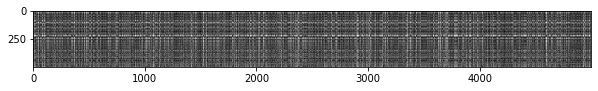

'\n注意距离矩阵中的结构化模式，其中一些行或列明显更亮。 （请注意，在默认配色方案中，黑色表示距离较近，而白色表示距离较远。）\n'

In [11]:
plt.imshow(dists, interpolation='none') # interpolation 插值方法，默认为nearest 如果interpolation = 'none'，则不执行插值

plt.show()
"""
注意距离矩阵中的结构化模式，其中一些行或列明显更亮。 （请注意，在默认配色方案中，黑色表示距离较近，而白色表示距离较远。）
"""

In [12]:
y_test_pred = classifier.predict_labels(dists, k=1) #最接近他的k个邻居
num_correct = np.sum(y_test_pred == y_test) # 返回正确的数量
accuracy = float(num_correct) / num_test
print("Got %d/%d correct => accuracy: %f" %(num_correct, num_test, accuracy))

Got 137/500 correct => accuracy: 0.274000


In [13]:
y_test_pred = classifier.predict_labels(dists, k=5) #最接近他的k个邻居中的出现频率最高的那个标签
num_correct = np.sum(y_test_pred == y_test) # 返回正确的数量
accuracy = float(num_correct) / num_test
print("Got %d/%d correct => accuracy: %f" %(num_correct, num_test, accuracy))
# 这个结果并没有显著提升， 需要扩展训练集或者说修改计算距离的公式，比如说 曼哈顿 距离

Got 139/500 correct => accuracy: 0.278000


In [14]:
# 通过部分向量化来加速距离矩阵的运算
dists_one = classifier.compute_distances_one_loop(X_test)

# 将矩阵转换为向量并计算它们之间的欧几里得距离
difference = np.linalg.norm(dists - dists_one, ord = 'fro') # ord Frobenius 范数
print("One loop difference was: %f" % (difference, ))
if difference < 0.001:
  print("Good! The distance matrices are the same")
else:
  print("Un-ch! The distance matrices are different")

One loop difference was: 0.000000
Good! The distance matrices are the same


In [15]:
dists_two = classifier.compute_distances_no_loops(X_test)

difference = np.linalg.norm(dists - dists_two, ord='fro')
print("No loop difference was: %f" % (difference, ))
if difference < 0.001:
  print("Good! The distance matrices are the same")
else:
  print("Uh-oh! The distance matrices are different")

No loop difference was: 0.000000
Good! The distance matrices are the same


In [16]:
# 测定三种不同求距离方式的时间
# 第三种会比另外两种快很多， 这在当下时间就是生命的情况下很重要

def time_function(f, *args):
  import time
  tic = time.time()
  f(*args)
  toc = time.time()
  return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print("Two loop version took %f seconds" % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print("One loop version took %f seconds" % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print("No loop version took %f seconds" % no_loop_time)

Two loop version took 39.068699 seconds
One loop version took 31.916171 seconds
No loop version took 0.498164 seconds


In [17]:
# 以下就是交叉验证的方式
"""
在机器学习中，当数据量不是很充足时，交叉验证是一种不错的模型选择方法（深度学习数据量要求很大，一般是不采用交叉验证的，因为它太费时间）
"""
num_folds = 5 # 将数据分为5份
k_choices = [1, 3, 5, 8, 10, 12, 15,20, 50, 100]
X_train_folds = []
y_train_folds = []


X_train_folds = np.array_split(X_train, num_folds) #将数据集平均分为5份
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {} # 以字典的形式来存取k 及其对应的 正确率

for k in k_choices:
  k_to_accuracies[k] = []
  for i in range(num_folds):
    Xtr = np.array(X_train_folds[:i] + X_train_folds[i + 1:])
    ytr = np.array(y_train_folds[:i] + y_train_folds[i + 1:])
    Xtr = np.reshape(Xtr, (Xtr.shape[0] * Xtr.shape[1], Xtr.shape[2]))
    ytr = np.reshape(ytr, ytr.shape[0] * ytr.shape[1])
    classifier.train(Xtr, ytr)
    y_val = classifier.predict(X_train_folds[i], k=k, num_loops=0)
    num_correct = np.sum(y_train_folds[i] == y_val)
    acc = float(num_correct) / len(y_train_folds[i])
    k_to_accuracies[k].append(acc)


for k in sorted(k_to_accuracies):
  sum_accuracy=0
  for accuracy in k_to_accuracies[k]:
    print('k = %d, accuracy = %f' % (k, accuracy))
    sum_accuracy += accuracy
  print("The average accuracy is : %f" % (sum_accuracy/5))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
The average accuracy is : 0.265600
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
The average accuracy is : 0.249600
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
The average accuracy is : 0.273200
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
The average accuracy is : 0.276000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
The average accuracy is : 0.280200
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
The a

上面这段代码显示10是最优的

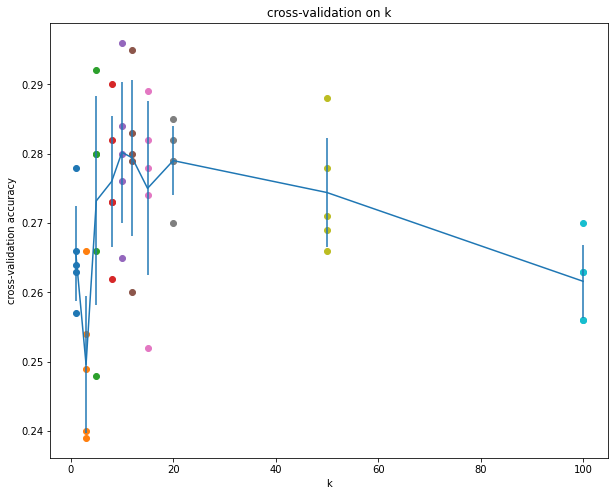

In [18]:
for kc in k_choices:
    accuracies=k_to_accuracies[kc]
    plt.scatter([kc]*len(accuracies),accuracies) 

accuracies_mean=np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std=np.array([np.std(v) for k ,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices,accuracies_mean,yerr=accuracies_std)
plt.title('cross-validation on k')
plt.xlabel('k')
plt.ylabel('cross-validation accuracy')
plt.show()

In [20]:
best_k = 10
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

y_test_pred = classifier.predict(X_test, k = best_k)

num_correct = np.sum(y_test_pred==y_test)
accuracy=float(num_correct)/num_test
print('got %d / %d correct => accuracy: %f' % (num_correct,num_test,accuracy))

got 141 / 500 correct => accuracy: 0.282000
